<a href="https://colab.research.google.com/github/Favour-Umeh/ARI5118/blob/main/Feature_Pyramid_Network_Annotated_Code_Walkthrough.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building Feature Pyramid Networks (FPNs) from Scratch
A hands-on tutorial to understand multi-scale feature extraction for object detection
In this notebook, we'll implement a complete Feature Pyramid Network (FPN) step by step. The objectives includes the follwing:
- Why single-scale detectors fail on small/medium objects
- How FPN combines high-level semantics with fine-grained localization
- How to build the bottom-up backbone, top-down pathway, and lateral connections
- How anchors are assigned to different pyramid levels
- Practical visualizations that reveal what each pyramid level "sees"
Let's start from first principles.

## 1. Setup and Imports
We'll use PyTorch for the CNN backbone, OpenCV for image loading, and Matplotlib for visualizations.

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

# Set Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# For reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


# 2. Load and Preprocess a Sample Image
We'll use a street scene image that contains objects of various sizes (cars, pedestrians, traffic signs) to illustrate multi-scale detection.

Original image size: 800 x 600


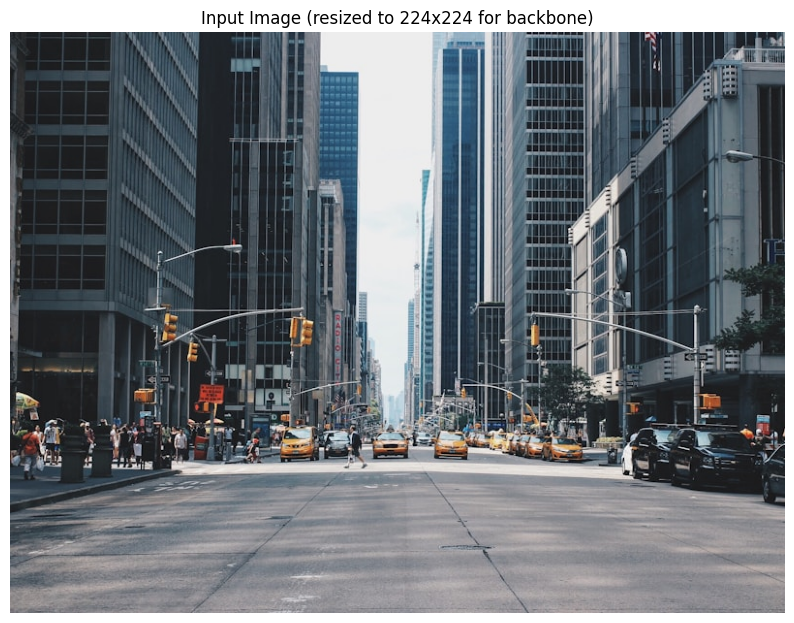

In [14]:
# Load a sample image (street view from URL)
url = "https://images.unsplash.com/photo-1449824913935-59a10b8d2000?w=800&h=600&fit=crop"
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert('RGB')
img_np = np.array(img)
h, w = img_np.shape[:2]
print(f"Original image size: {w} x {h}")

# Preprocessing for ResNet
transform = transforms.Compose([
transforms.Resize((224, 224)),
transforms.ToTensor(),
transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
input_tensor = transform(img).unsqueeze(0).to(device) # [1, 3, 224, 224]

# Display
plt.figure(figsize=(10, 8))
plt.imshow(img_np)
plt.title("Input Image (resized to 224x224 for backbone)")
plt.axis('off')
plt.show()

# 3. Backbone: Extracting Multi-Scale Features (Bottom-Up Pathway)
The backbone (ResNet50) naturally produces feature maps at different resolutions due to strided convolutions and pooling. We denote these as C2, C3, C4, C5.
| Level | Output of | Spatial stride | Resolution (224x224 input) | Semantic strength |
|-------|----------------|----------------|----------------------------|-------------------|
| C2 | layer1 | 4 | 56x56 | Low |
| C3 | layer2 | 8 | 28x28 | Medium |
C4 | layer3 | 16 | 14x14 | High |
| C5 | layer4 | 32 | 7x7 | Very high |
Why this matters: Small objects (e.g., 20x20 pixels) disappear in C5 (only 1 cell covers them) but are well represented in C2 (~25 cells). However, C2 lacks semantic power to classify them correctly.

In [15]:
class BackboneExtractor(nn.Module):
    """Extract C2, C3, C4, C5 from a pretrained ResNet"""
    def __init__(self, backbone_name='resnet50'):
        super().__init__()

        # Load pretrained ResNet
        if backbone_name == 'resnet50':
            resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        else:
            raise ValueError("Only resnet50 supported for now")

        # Extract layers: conv1, bn1, relu, maxpool, then layers 1-4
        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        self.layer1 = resnet.layer1 # C2: stride 4
        self.layer2 = resnet.layer2 # C3: stride 8
        self.layer3 = resnet.layer3 # C4: stride 16
        self.layer4 = resnet.layer4 # C5: stride 32

    def forward(self, x):

        # Initial stem
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x) # after this: stride 4, 56x56 for 224 input

        c2 = self.layer1(x) # stride 4, channels 256
        c3 = self.layer2(c2) # stride 8, channels 512
        c4 = self.layer3(c3) # stride 16, channels 1024
        c5 = self.layer4(c4) # stride 32, channels 2048

        return c2, c3, c4, c5

# Instantiate and run
backbone = BackboneExtractor().to(device)
backbone.eval()
with torch.no_grad():
    c2, c3, c4, c5 = backbone(input_tensor)

print("Feature map shapes:")
print(f"C2: {c2.shape} (stride 4)") # [1, 256, 56, 56]
print(f"C3: {c3.shape} (stride 8)") # [1, 512, 28, 28]
print(f"C4: {c4.shape} (stride 16)") # [1, 1024, 14, 14]
print(f"C5: {c5.shape} (stride 32)") # [1, 2048, 7, 7]

Feature map shapes:
C2: torch.Size([1, 256, 56, 56]) (stride 4)
C3: torch.Size([1, 512, 28, 28]) (stride 8)
C4: torch.Size([1, 1024, 14, 14]) (stride 16)
C5: torch.Size([1, 2048, 7, 7]) (stride 32)


# Visualize the Feature Maps
Let's see how the spatial resolution decreases while semantic content becomes more abstract.

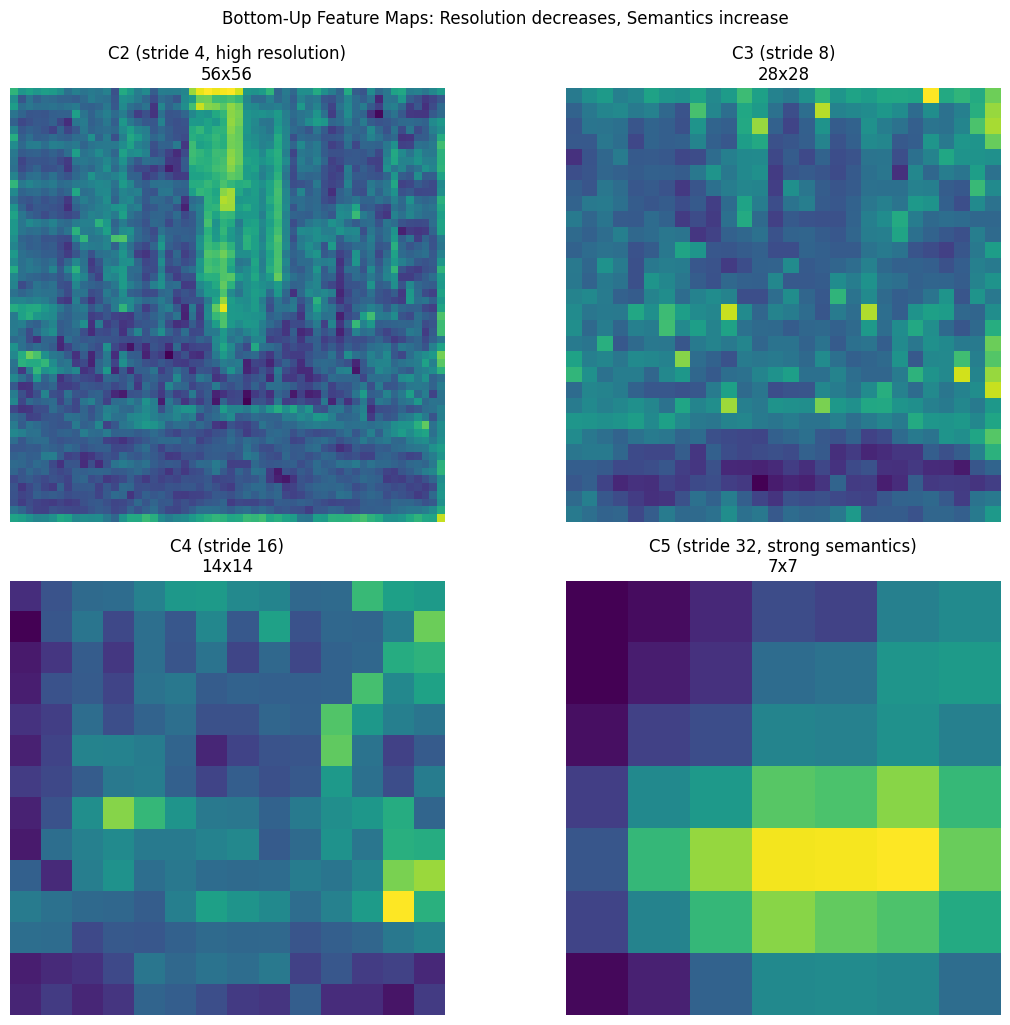

In [16]:
def visualize_feature_map(feature_map, title, ax):
    """Show the mean of channels as a heatmap"""
    # Average over channels -> [H, W]
    mean_act = feature_map[0].mean(dim=0).cpu().numpy()
    ax.imshow(mean_act, cmap='viridis')
    ax.set_title(f"{title}\n{feature_map.shape[2]}x{feature_map.shape[3]}")
    ax.axis('off')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
visualize_feature_map(c2, "C2 (stride 4, high resolution)", axes[0,0])
visualize_feature_map(c3, "C3 (stride 8)", axes[0,1])
visualize_feature_map(c4, "C4 (stride 16)", axes[1,0])
visualize_feature_map(c5, "C5 (stride 32, strong semantics)", axes[1,1])
plt.tight_layout()
plt.suptitle("Bottom-Up Feature Maps: Resolution decreases, Semantics increase", y=1.02)
plt.show()

Notice how C2 retains fine details (edges, textures) while C5 shows only coarse object activations. This is the scale dilemma FPN solves.

4. Lateral Connections and Top-Down Pathway
### Key Idea
The top-down pathway upsamples coarse, semantic-rich feature maps and adds them to fine-resolution maps via lateral connections. This gives every pyramid level both localization precision and strong semantics.
### Mathematical Formulation
For level i (starting from top):
1. Lateral projection:
L
i
=
Conv
1
×
1
(
C
i
)
L
i
​
 =Conv
1×1
​
 (C
i
​
 ) (reduce channels to 256)
2. Top-down fusion:
T
i
=
Upsample(P
i+1
​
 )+L
i
​
3. Final output:
P
i
=
Conv
3
×
3
(
T
i
)
P
i
​
 =Conv
3×3
​
 (T
i
​
 ) (reduce aliasing)
Where upsampling is usually 2x nearest neighbor.

In [17]:
class FPN(nn.Module):
    """Feature Pyramid Network built on top of backbone outputs C2-C5"""
    def __init__(self, in_channels=[256, 512, 1024, 2048], out_channels=256):
        super().__init__()

        # Lateral connections: 1x1 conv to reduce depth
        self.lateral_convs = nn.ModuleList([
            nn.Conv2d(ch, out_channels, kernel_size=1)
            for ch in in_channels
        ])
        # Smoothing convolutions: 3x3 after addition
        self.smooth_convs = nn.ModuleList([
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
            for _ in range(len(in_channels))
        ])
        self.out_channels = out_channels

    def forward(self, c_features):
        """
        c_features: list of [C2, C3, C4, C5] in order from high-res to low-res
        Returns: list of [P2, P3, P4, P5] with same spatial sizes as C2..C5 but 256 channels
        """
        # Apply lateral convs to get same channel dimension
        laterals = [lateral(c) for lateral, c in zip(self.lateral_convs, c_features)]

        # Top-down pathway: start from the highest level (C5 -> P5)
        pyramid = []

        # P5 is just lateral5 smoothed
        # Correct: use the last lateral and its corresponding smooth conv
        p5 = self.smooth_convs[-1](laterals[-1])
        pyramid.append(p5)

        # Iterate from top-1 down to bottom (P4, P3, P2)
        # laterals are C2, C3, C4, C5
        # We want to process C4, C3, C2
        for i in range(len(laterals) - 2, -1, -1):
            # Upsample previous pyramid level (P_{i+1}) by factor 2
            # pyramid[0] always refers to the *last generated* P level (e.g., P5, then P4, etc.)
            upsampled = F.interpolate(pyramid[0], size=laterals[i].shape[2:], mode='nearest')

            # Add lateral
            fused = upsampled + laterals[i]

            # Smooth
            p_i = self.smooth_convs[i](fused)

            # Insert at front to maintain order P2, P3, P4, P5
            pyramid.insert(0, p_i)

        return pyramid # [P2, P3, P4, P5]

# Build and run FPN
fpn = FPN(in_channels=[256, 512, 1024, 2048], out_channels=256).to(device)
with torch.no_grad():
    # c_features should be [C2, C3, C4, C5]
    p2, p3, p4, p5 = fpn([c2, c3, c4, c5])

print("FPN output shapes:")
print(f"P2: {p2.shape} (stride 4, 256 channels)")
print(f"P3: {p3.shape} (stride 8, 256 channels)")
print(f"P4: {p4.shape} (stride 16, 256 channels)")
print(f"P5: {p5.shape} (stride 32, 256 channels)")

FPN output shapes:
P2: torch.Size([1, 256, 56, 56]) (stride 4, 256 channels)
P3: torch.Size([1, 256, 28, 28]) (stride 8, 256 channels)
P4: torch.Size([1, 256, 14, 14]) (stride 16, 256 channels)
P5: torch.Size([1, 256, 7, 7]) (stride 32, 256 channels)


# Visualize the Effect of Lateral Connections
Let's compare C2 (pure backbone, high-res but weak semantics) vs P2 (enriched with top-down information). Watch how P2 highlights whole objects rather than just edges.

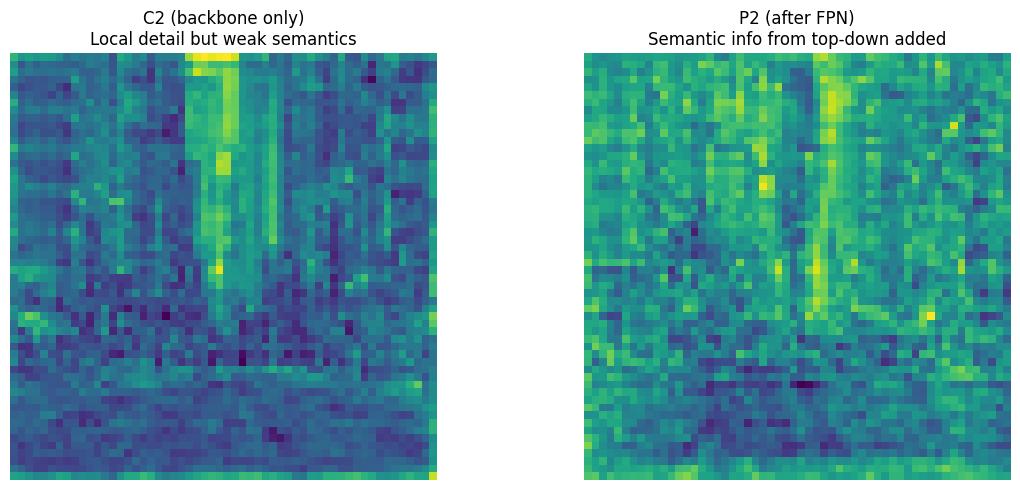

In [18]:
def plot_comparison(original, enhanced, title_orig, title_enhanced):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    mean_orig = original[0].mean(dim=0).cpu().numpy()
    mean_enh = enhanced[0].mean(dim=0).cpu().numpy()
    ax1.imshow(mean_orig, cmap='viridis')
    ax1.set_title(title_orig)
    ax1.axis('off')
    ax2.imshow(mean_enh, cmap='viridis')
    ax2.set_title(title_enhanced)
    ax2.axis('off')
    plt.tight_layout()
    plt.show()

plot_comparison(c2, p2, "C2 (backbone only)\nLocal detail but weak semantics",
"P2 (after FPN)\nSemantic info from top-down added")

Interpretation: P2 retains the fine resolution of C2 but now activates more uniformly over object regions because high-level semantics from C5/C4 have been propagated down. This is the magic of FPN.

# 5. Anchor Assignment to Pyramid Levels
In object detection, anchors (predefined bounding boxes) are assigned to different pyramid levels based on their scale. The original FPN uses:
- P2: anchors of area 32² pixels (on original image)
- P3: anchors of area 64² pixels
- P4: anchors of area 128² pixels
- P5: anchors of area 256² pixels
- P6 (optional): 512²
The assignment rule: an anchor of width w and height h (on original image) is assigned to level k where
[
k = \left\lfloor 4 + \log_2\left(\frac{\sqrt{w \cdot h}}{224}\right) \right\rfloor
]
because 224 is the typical input size and 224/2^4 = 14 (roughly P2 scale). Let's implement and visualize.

Anchor assignment based on object area:
Traffic sign    area=   900 pixels -> Pyramid P2
Pedestrian      area= 12000 pixels -> Pyramid P2
Car             area=  9600 pixels -> Pyramid P2
Bus             area= 60000 pixels -> Pyramid P4


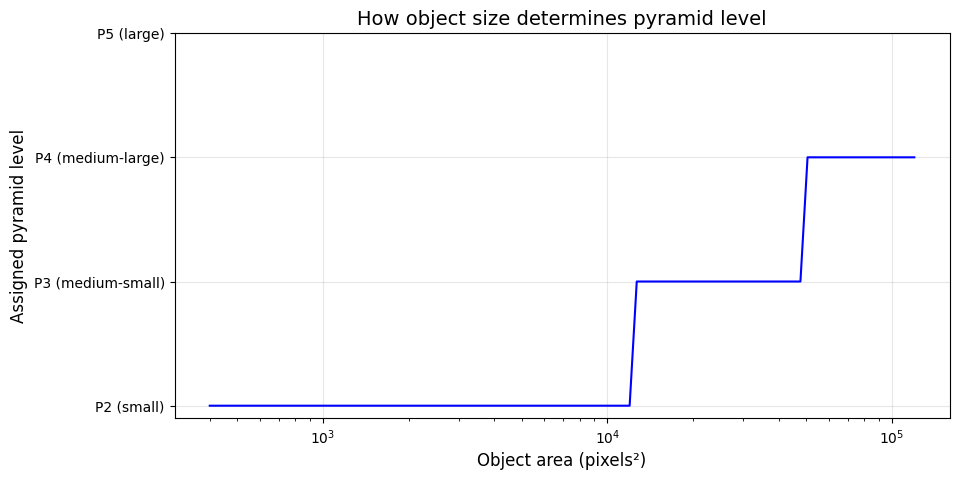

In [19]:
def assign_pyramid_level(anchor_area, base_scale=224):
    """
    anchor_area: area in pixels of anchor box (w*h) on original image
    Returns: pyramid level (2-5)
    """
    # Using formula from FPN paper: k = floor(4 + log2(sqrt(area)/224))
    scale = np.sqrt(anchor_area)
    k = int(np.floor(4 + np.log2(scale / base_scale)))
    # Clamp to valid levels
    return max(2, min(5, k))

# Example object sizes (in original image, before resizing to 224)
object_sizes = [
    ("Traffic sign", 30*30), # 30x30 pixels
    ("Pedestrian", 80*150), # 80x150
    ("Car", 120*80), # 120x80
    ("Bus", 300*200) # large
]

print("Anchor assignment based on object area:")
for name, area in object_sizes:
    level = assign_pyramid_level(area)
    print(f"{name:15s} area={area:6d} pixels -> Pyramid P{level}")

# Visualize the mapping over a range of object sizes
areas = np.logspace(np.log10(20*20), np.log10(400*300), 100)
levels = [assign_pyramid_level(a) for a in areas]

plt.figure(figsize=(10, 5))
plt.plot(areas, levels, 'b-')
plt.xscale('log')
plt.xlabel('Object area (pixels²)', fontsize=12)
plt.ylabel('Assigned pyramid level', fontsize=12)
plt.title('How object size determines pyramid level', fontsize=14)
plt.grid(True, alpha=0.3)
plt.yticks([2,3,4,5], ['P2 (small)', 'P3 (medium-small)', 'P4 (medium-large)', 'P5 (large)'])
plt.show()

# 6. Practical Application: Adding a Simple Detection Head
We'll attach a minimal detection head to each pyramid level. In reality, this would be a class + box regression subnet, but here we'll just simulate region proposals to show how multi-scale features are used.

P2 objectness map shape: torch.Size([1, 3, 56, 56])
P3 objectness map shape: torch.Size([1, 3, 28, 28])
P4 objectness map shape: torch.Size([1, 3, 14, 14])
P5 objectness map shape: torch.Size([1, 3, 7, 7])


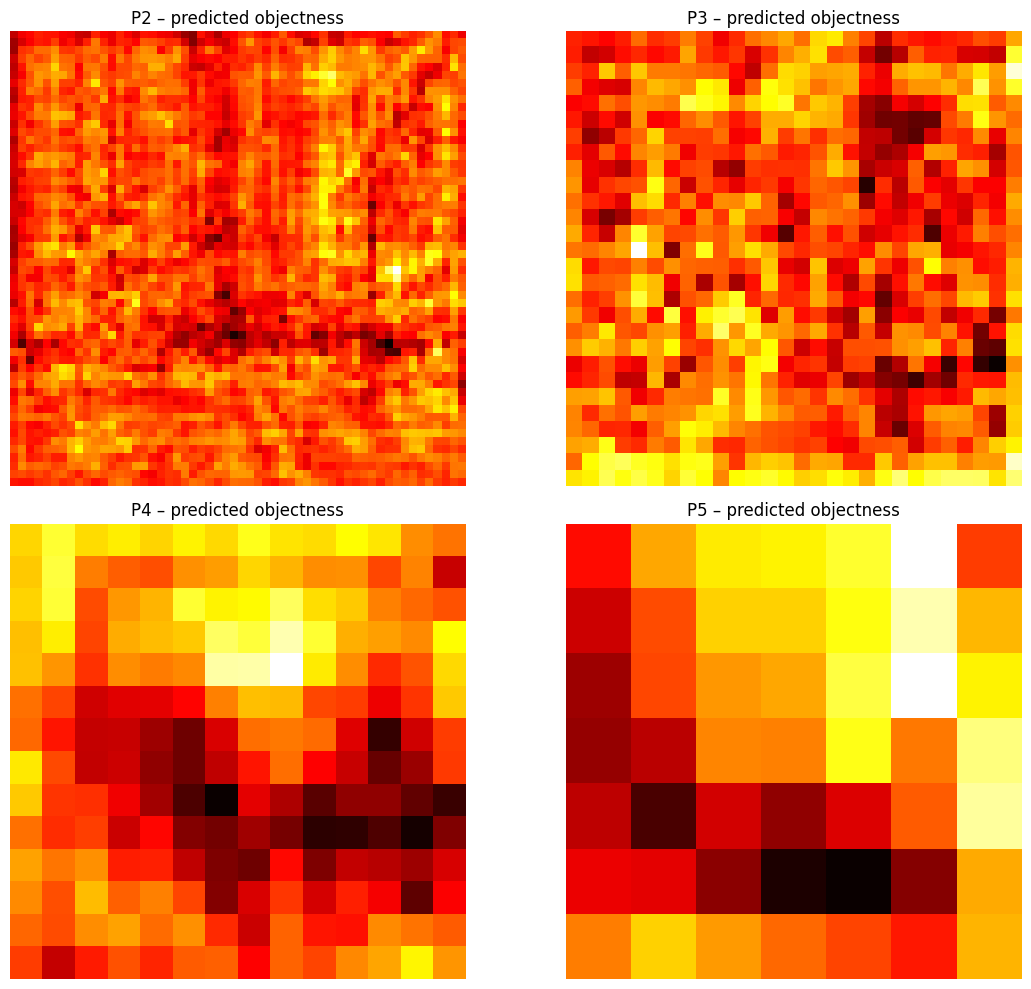

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F # FPN uses F.interpolate
import matplotlib.pyplot as plt

# Additional imports needed for BackboneExtractor and input_tensor
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np
from PIL import Image
import requests
from io import BytesIO

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- BackboneExtractor class definition (from YCBKUXFcnC6o) ---
class BackboneExtractor(nn.Module):
    """Extract C2, C3, C4, C5 from a pretrained ResNet"""
    def __init__(self, backbone_name='resnet50'):
        super().__init__()
        if backbone_name == 'resnet50':
            resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        else:
            raise ValueError("Only resnet50 supported for now")
        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        self.layer1 = resnet.layer1 # C2: stride 4
        self.layer2 = resnet.layer2 # C3: stride 8
        self.layer3 = resnet.layer3 # C4: stride 16
        self.layer4 = resnet.layer4 # C5: stride 32

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        c2 = self.layer1(x)
        c3 = self.layer2(c2)
        c4 = self.layer3(c3)
        c5 = self.layer4(c4)
        return c2, c3, c4, c5

# --- input_tensor creation (simplified from 1pLj9vLqmhNY) ---
url = "https://images.unsplash.com/photo-1449824913935-59a10b8d2000?w=800&h=600&fit=crop"
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert('RGB')
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
input_tensor = transform(img).unsqueeze(0).to(device)

# --- c2, c3, c4, c5 generation (from YCBKUXFcnC6o) ---
backbone = BackboneExtractor().to(device)
backbone.eval()
with torch.no_grad():
    c2, c3, c4, c5 = backbone(input_tensor)

# --- FPN class definition (already added in previous turn) ---
class FPN(nn.Module):
    """Feature Pyramid Network built on top of backbone outputs C2-C5"""
    def __init__(self, in_channels=[256, 512, 1024, 2048], out_channels=256):
        super().__init__()
        self.lateral_convs = nn.ModuleList([
            nn.Conv2d(ch, out_channels, kernel_size=1)
            for ch in in_channels
        ])
        self.smooth_convs = nn.ModuleList([
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
            for _ in range(len(in_channels))
        ])
        self.out_channels = out_channels

    def forward(self, c_features):
        laterals = [lateral(c) for lateral, c in zip(self.lateral_convs, c_features)]
        pyramid = []
        p5 = self.smooth_convs[-1](laterals[-1])
        pyramid.append(p5)
        for i in range(len(laterals) - 2, -1, -1):
            upsampled = F.interpolate(pyramid[0], size=laterals[i].shape[2:], mode='nearest')
            fused = upsampled + laterals[i]
            p_i = self.smooth_convs[i](fused)
            pyramid.insert(0, p_i)
        return pyramid # [P2, P3, P4, P5]

# --- SimpleDetectionHead class definition (already there) ---
class SimpleDetectionHead(nn.Module):
    """A dummy head that outputs objectness score for each spatial location"""
    def __init__(self, in_channels, num_anchors=3):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, num_anchors, kernel_size=3, padding=1)

    def forward(self, x):
        return torch.sigmoid(self.conv(x)) # objectness probability

# Attach heads to P2-P5
heads = nn.ModuleList([SimpleDetectionHead(256) for _ in range(4)])

# Original FPN calculation block for p2, p3, p4, p5
fpn = FPN(in_channels=[256, 512, 1024, 2048], out_channels=256).to(device)
with torch.no_grad():
    p2, p3, p4, p5 = fpn([c2, c3, c4, c5])

with torch.no_grad():
    p_features = [p2, p3, p4, p5]
    objectness_maps = [head(feat) for head, feat in zip(heads, p_features)]

# Each objectness map has shape [1, num_anchors, H, W]
for i, om in enumerate(objectness_maps):
    print(f"P{i+2} objectness map shape: {om.shape}")

# Visualize the strongest objectness activations (averaged over anchors)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for idx, (om, ax) in enumerate(zip(objectness_maps, axes.flat)):
    heatmap = om[0].mean(dim=0).cpu().numpy()
    ax.imshow(heatmap, cmap='hot')
    ax.set_title(f"P{idx+2} – predicted objectness")
    ax.axis('off')
plt.tight_layout()
plt.show()

Notice how different pyramid levels respond to objects of different sizes. P2 highlights many small details (possibly false positives), while P5 only fires on large coherent regions. In a full detector, each level would only predict boxes of its assigned scale.

# 7. Parameter Effects and Ablation Studies
### 7.1 Changing the Upsampling Method
Nearest neighbor is fast but can introduce aliasing. Let's compare nearest vs bilinear.

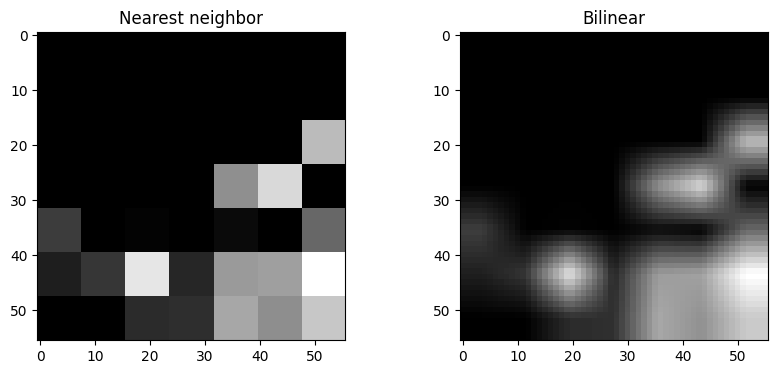

In [21]:
def compare_upsampling(feature, target_size):
    nearest = F.interpolate(feature, size=target_size, mode='nearest')
    bilinear = F.interpolate(feature, size=target_size, mode='bilinear', align_corners=False)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(nearest[0,0].cpu().numpy(), cmap='gray')
    ax1.set_title("Nearest neighbor")
    ax2.imshow(bilinear[0,0].cpu().numpy(), cmap='gray')
    ax2.set_title("Bilinear")
    plt.show()

# Use one channel of C5 (semantic but coarse)
sample = c5[:, 0:1, :, :] # [1,1,7,7]
compare_upsampling(sample, (56,56))

Observation: Nearest neighbor produces blocky artifacts but preserves peak values. Bilinear gives smoother transitions. The original FPN uses nearest for speed, but some variants use bilinear for slightly better accuracy.

### 7.2 Changing Lateral Connection Channel Dimensions
FPN typically uses 256 output channels. What if we use fewer or more?

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Try different output channels
for out_ch in [128, 256, 512]:
    fpn_test = FPN(in_channels=[256,512,1024,2048], out_channels=out_ch).to(device)
    with torch.no_grad():
        p2_test, _, _, _ = fpn_test([c2, c3, c4, c5])
    print(f"out_channels={out_ch:3d} -> P2 shape {p2_test.shape} (params in lateral convs: "
          f"{sum(p.numel() for p in fpn_test.lateral_convs.parameters()):,})")

out_channels=128 -> P2 shape torch.Size([1, 128, 56, 56]) (params in lateral convs: 492,032)
out_channels=256 -> P2 shape torch.Size([1, 256, 56, 56]) (params in lateral convs: 984,064)
out_channels=512 -> P2 shape torch.Size([1, 512, 56, 56]) (params in lateral convs: 1,968,128)


More channels increase capacity but also computational cost. 256 is a sweet spot – enough to carry semantic info without blowing up the detection heads.

## 8. From Theory to Practice: Integration with Modern Detectors
The FPN we built is the exact "neck" used in:
- Faster R-CNN + FPN (region proposal + classification)
- Mask R-CNN (adds mask prediction branch)
- RetinaNet (dense anchor-based detector)
Each detection head on P2-P5 predicts:
- Object class scores (K classes)
- Bounding box offsets (4 numbers)
- (Optional) segmentation mask
The key advantage: you train one model that handles all scales, no image pyramids needed.

## 9. Summary and Key Takeaways
1. Problem solved: CNNs lose spatial detail in deep layers, making small object detection hard. FPN fixes this by propagating high-level semantics down to high-resolution maps.
2. Architecture components:
- Bottom-up backbone (C2-C5)
- Lateral 1x1 convs (align channels)
- Top-down upsampling + addition
- Smooth 3x3 convs
3. Anchor assignment: Object size determines pyramid level via
k
=
⌊
4
+
log
⁡
2
(
scale
/
224
)
⌋
k=⌊4+log
2
​
 (scale/224)⌋.
4. Practical gains: FPN improves small object AP by 10+ points on COCO with minimal inference cost.
5. Extensions (as in the literature):
- GraphFPN: dynamic graph topology instead of fixed grid
- LFPN: latent-space fusion to capture long-range dependencies
- MSRA-FPN: residual aggregation to prevent information degradation
- DM-FPN: domain adaptation for remote sensing
Now you have a working FPN implementation and understand the design decisions behind each component. Experiment with your own images and see how the pyramid responds to different object scales!

## 10. References
- Lin, T.-Y., Dollár, P., Girshick, R., He, K., Hariharan, B., & Belongie, S. (2017). Feature Pyramid Networks for Object Detection. CVPR.
- Zhao, G., Ge, W., & Yu, Y. (2021). GraphFPN: Graph Feature Pyramid Network for Object Detection. ICCV.
- Xie, J., Pang, Y., Nie, J., Cao, J., & Han, J. (2022). Latent Feature Pyramid Network for Object Detection. IEEE TMM.
